# Mental Health Trend Monitor -- Notebook 01 : Analyse Exploratoire Initiale


---

## Objectif

Ce notebook realise l'analyse exploratoire initiale du dataset Reddit collecte via l'API PRAW.  
Il couvre les points suivants :

- Chargement et inspection structurelle du dataset
- Analyse des valeurs manquantes et des colonnes inutilisables
- Verification du desequilibre de la variable cible `is_distress`
- Distribution des features numeriques et categorielles
- Identification des problemes a traiter en Phase 2

---

## 0. Imports et configuration

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

os.makedirs('../figures', exist_ok=True)

COLORS = ['#4c8fbd', '#c0523a']

print('Imports OK')

Imports OK


---
## 1. Chargement du dataset

In [10]:
df = pd.read_csv('../data/dataset.csv')

print(f'Dataset charge avec succes.')
print(f'   Lignes   : {df.shape[0]:,}')
print(f'   Colonnes : {df.shape[1]}')

Dataset charge avec succes.
   Lignes   : 12,000
   Colonnes : 12


In [11]:
df.head(10)

,hour_of_day,title_length_chars,body_length_chars,title_ends_with_question,is_nsfw,has_url_in_body,author_is_new,author_comment_karma,author_post_karma,flair_text,subreddit,is_distress
0,18,47,0,0,0,0,-1,-1,-1,NaN,CasualConversation,0
1,23,68,0,1,0,0,-1,-1,-1,NaN,AskReddit,0
2,16,18,388,0,0,0,-1,-1,-1,Need Support,mentalhealth,1
3,21,39,0,0,0,0,-1,-1,-1,NaN,fitness,0
4,9,27,1545,0,0,0,-1,-1,-1,NaN,depression,1
5,12,38,0,1,0,0,-1,-1,-1,Question,productivity,0
6,7,64,0,1,0,0,-1,-1,-1,NaN,AskReddit,0
7,16,95,0,0,0,0,-1,-1,-1,NaN,fitness,0
8,6,77,572,0,0,0,-1,-1,-1,:chat: Just Chatting,CasualConversation,0
9,11,54,0,1,0,0,-1,-1,-1,NaN,AskReddit,0


---
## 2. Inspection structurelle

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   hour_of_day               12000 non-null  int64
 1   title_length_chars        12000 non-null  int64
 2   body_length_chars         12000 non-null  int64
 3   title_ends_with_question  12000 non-null  int64
 4   is_nsfw                   12000 non-null  int64
 5   has_url_in_body           12000 non-null  int64
 6   author_is_new             12000 non-null  int64
 7   author_comment_karma      12000 non-null  int64
 8   author_post_karma         12000 non-null  int64
 9   flair_text                5116 non-null   str  
 10  subreddit                 12000 non-null  str  
 11  is_distress               12000 non-null  int64
dtypes: int64(10), str(2)
memory usage: 1.1 MB


In [13]:
df.describe().round(2)

,hour_of_day,title_length_chars,body_length_chars,title_ends_with_question,is_nsfw,has_url_in_body,author_is_new,author_comment_karma,author_post_karma,is_distress
count,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.0,12000.0,12000.0,12000.00
mean,11.48,58.25,265.17,0.48,0.03,0.01,-1.0,-1.0,-1.0,0.15
std,6.89,34.57,595.26,0.50,0.17,0.08,0.0,0.0,0.0,0.36
min,0.00,1.00,0.00,0.00,0.00,0.00,-1.0,-1.0,-1.0,0.00
25%,6.00,34.00,0.00,0.00,0.00,0.00,-1.0,-1.0,-1.0,0.00
50%,11.00,53.00,0.00,0.00,0.00,0.00,-1.0,-1.0,-1.0,0.00
75%,17.00,75.00,281.25,1.00,0.00,0.00,-1.0,-1.0,-1.0,0.00
max,23.00,300.00,10664.00,1.00,1.00,1.00,-1.0,-1.0,-1.0,1.00


In [14]:
df.describe(include='object')

,flair_text,subreddit
count,5116,12000
unique,67,8
top,Question,CasualConversation
freq,1092,2550


### Schema des colonnes

| Colonne | Type | Description |
|---|---|---|
| `hour_of_day` | Numerique (int) | Heure de publication du post (0-23) |
| `title_length_chars` | Numerique (int) | Longueur du titre en caracteres |
| `body_length_chars` | Numerique (int) | Longueur du corps du post en caracteres |
| `title_ends_with_question` | Binaire (0/1) | Le titre se termine-t-il par un point d'interrogation |
| `is_nsfw` | Binaire (0/1) | Le post est-il marque NSFW |
| `has_url_in_body` | Binaire (0/1) | Le corps contient-il une URL |
| `author_is_new` | Binaire / -1 | Le compte auteur est-il recent |
| `author_comment_karma` | Numerique / -1 | Karma commentaires de l'auteur |
| `author_post_karma` | Numerique / -1 | Karma posts de l'auteur |
| `flair_text` | Categorielle | Etiquette de flair associee au post |
| `subreddit` | Categorielle | Subreddit source du post |
| `is_distress` | **Cible** (0/1) | **0** = non-detresse, **1** = detresse |

---
## 3. Analyse des valeurs manquantes

In [15]:
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Valeurs manquantes' : missing_count,
    'Pourcentage (%)' : missing_pct
}).sort_values('Valeurs manquantes', ascending=False)

print(missing_df.to_string())

                          Valeurs manquantes  Pourcentage (%)
flair_text                              6884            57.37
hour_of_day                                0             0.00
body_length_chars                          0             0.00
title_length_chars                         0             0.00
title_ends_with_question                   0             0.00
is_nsfw                                    0             0.00
author_is_new                              0             0.00
has_url_in_body                            0             0.00
author_comment_karma                       0             0.00
author_post_karma                          0             0.00
subreddit                                  0             0.00
is_distress                                0             0.00


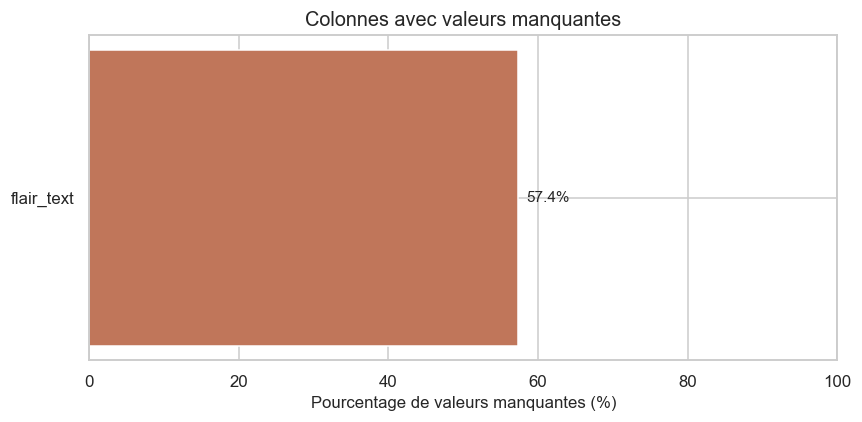

In [16]:
cols_with_missing = missing_df[missing_df['Valeurs manquantes'] > 0]

if len(cols_with_missing) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(
        cols_with_missing.index,
        cols_with_missing['Pourcentage (%)'],
        color='#c0765a', edgecolor='white'
    )
    ax.set_xlabel('Pourcentage de valeurs manquantes (%)')
    ax.set_title('Colonnes avec valeurs manquantes')
    ax.set_xlim(0, 100)
    for bar, pct in zip(bars, cols_with_missing['Pourcentage (%)']):
        ax.text(pct + 1, bar.get_y() + bar.get_height() / 2,
                f'{pct:.1f}%', va='center', fontsize=10)
    plt.tight_layout()
    plt.savefig('../figures/missing_values.png', bbox_inches='tight')
    plt.show()
else:
    print('Aucune valeur manquante detectee.')

> **Observation :** La colonne `flair_text` presente **57.4 % de valeurs manquantes** (6 884 / 12 000 posts).
> Elle reste potentiellement utile pour les posts qui en disposent, mais necessite une strategie d'imputation en Phase 2 (remplacement par `"No Flair"`).

---
## 4. Colonnes inutilisables -- valeurs constantes a -1

In [17]:
author_cols = ['author_is_new', 'author_comment_karma', 'author_post_karma']

print('Valeurs uniques par colonne auteur :')
for col in author_cols:
    unique_vals = df[col].unique()
    pct_minus1  = (df[col] == -1).mean() * 100
    print(f'  {col:30s} -> valeurs uniques : {unique_vals}  |  pct = -1 : {pct_minus1:.1f}%')

Valeurs uniques par colonne auteur :
  author_is_new                  -> valeurs uniques : [-1]  |  pct = -1 : 100.0%
  author_comment_karma           -> valeurs uniques : [-1]  |  pct = -1 : 100.0%
  author_post_karma              -> valeurs uniques : [-1]  |  pct = -1 : 100.0%


> **Observation critique :** Les trois colonnes `author_is_new`, `author_comment_karma` et `author_post_karma` contiennent **100 % de valeurs egales a -1**.
> La collecte PRAW n'a pas pu recuperer ces informations (permissions insuffisantes ou comptes supprimes).
> Ces colonnes seront **supprimees en Phase 2** car elles n'apportent aucune information discriminante.

---
## 5. Distribution de la variable cible `is_distress`

In [18]:
counts = df['is_distress'].value_counts().sort_index()
props  = df['is_distress'].value_counts(normalize=True).sort_index().mul(100).round(2)

distress_summary = pd.DataFrame({
    'Classe'     : ['Non-detresse (0)', 'Detresse (1)'],
    'Effectif'   : [counts[0], counts[1]],
    'Proportion' : [f'{props[0]:.2f} %', f'{props[1]:.2f} %']
})
print(distress_summary.to_string(index=False))
print(f'\nRatio classe minoritaire / total : {props[1]:.2f} %  (exigence : 5 % -- 25 %)')

          Classe  Effectif Proportion
Non-detresse (0)     10200    85.00 %
    Detresse (1)      1800    15.00 %

Ratio classe minoritaire / total : 15.00 %  (exigence : 5 % -- 25 %)


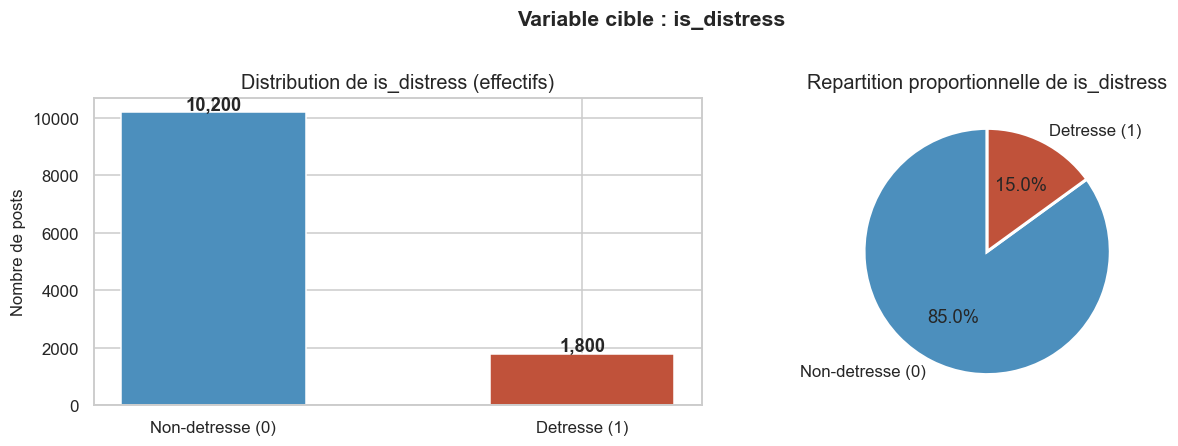

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barplot
axes[0].bar(
    ['Non-detresse (0)', 'Detresse (1)'],
    [counts[0], counts[1]],
    color=COLORS, edgecolor='white', width=0.5
)
axes[0].set_title('Distribution de is_distress (effectifs)')
axes[0].set_ylabel('Nombre de posts')
for i, v in enumerate([counts[0], counts[1]]):
    axes[0].text(i, v + 80, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    [counts[0], counts[1]],
    labels=['Non-detresse (0)', 'Detresse (1)'],
    autopct='%1.1f%%',
    colors=COLORS,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Repartition proportionnelle de is_distress')

plt.suptitle('Variable cible : is_distress', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../figures/class_distribution.png', bbox_inches='tight')
plt.show()

> **Verification de la contrainte de desequilibre :**
> Le dataset presente un ratio de **15 % de posts de detresse** (1 800 / 12 000).
> Ce ratio est **conforme a l'exigence du cahier des charges** (5 % -- 25 % de classe minoritaire).
> La contrainte de taille est egalement respectee : 12 000 lignes >= 10 000 requis.

---
## 6. Distribution de `is_distress` par subreddit

In [20]:
cross = df.groupby('subreddit')['is_distress'].value_counts().unstack(fill_value=0)
cross.columns = ['Non-detresse (0)', 'Detresse (1)']
cross['Total'] = cross.sum(axis=1)
cross['% Detresse'] = (cross['Detresse (1)'] / cross['Total'] * 100).round(1)
print(cross.sort_values('% Detresse', ascending=False).to_string())

                    Non-detresse (0)  Detresse (1)  Total  % Detresse
subreddit                                                            
anxiety                            0           450    450       100.0
SuicideWatch                       0           450    450       100.0
mentalhealth                       0           450    450       100.0
depression                         0           450    450       100.0
AskReddit                       2550             0   2550         0.0
CasualConversation              2550             0   2550         0.0
fitness                         2550             0   2550         0.0
productivity                    2550             0   2550         0.0


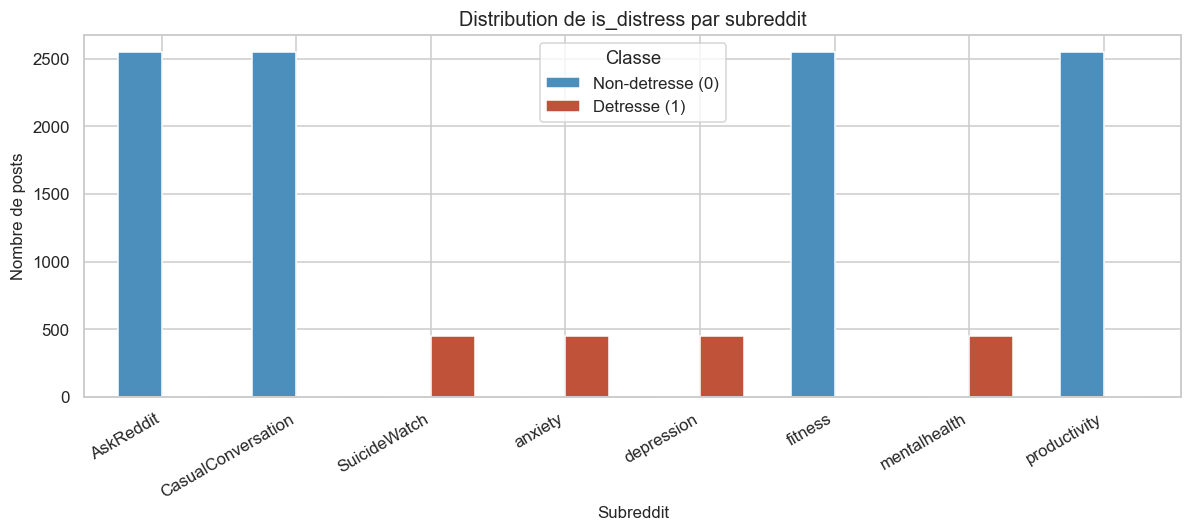

In [21]:
cross_plot = df.groupby(['subreddit', 'is_distress']).size().unstack(fill_value=0)
cross_plot.columns = ['Non-detresse (0)', 'Detresse (1)']

fig, ax = plt.subplots(figsize=(11, 5))
cross_plot.plot(kind='bar', ax=ax, color=COLORS, edgecolor='white', width=0.65)
ax.set_title('Distribution de is_distress par subreddit')
ax.set_xlabel('Subreddit')
ax.set_ylabel('Nombre de posts')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Classe')
plt.tight_layout()
plt.savefig('../figures/distress_by_subreddit.png', bbox_inches='tight')
plt.show()

> **Observation -- Fuite de donnees potentielle (Data Leakage) :**
> La variable `subreddit` est **parfaitement correlee** a la variable cible `is_distress` :
>
> | Subreddit | is_distress |
> |---|---|
> | `SuicideWatch`, `anxiety`, `depression`, `mentalhealth` | 100 % Detresse (1) |
> | `fitness`, `productivity`, `AskReddit`, `CasualConversation` | 100 % Non-detresse (0) |
>
> Si `subreddit` est conservee comme feature d'entree, le modele pourra **predire parfaitement sans apprendre du contenu reel des posts**, ce qui constitue un biais majeur.
> **Action a mener en Phase 2 :** supprimer la colonne `subreddit` avant l'entrainement.

---
## 7. Distribution des features numeriques

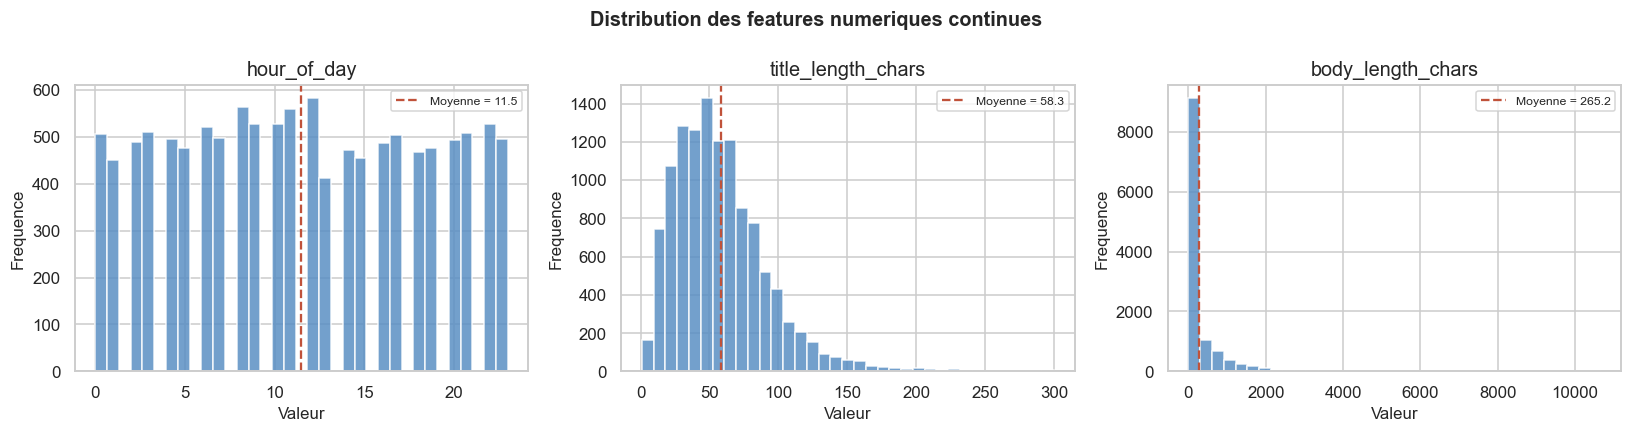

In [22]:
num_cols = ['hour_of_day', 'title_length_chars', 'body_length_chars']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    ax.hist(df[col], bins=35, color='#5a8fc4', edgecolor='white', alpha=0.85)
    ax.set_title(col)
    ax.set_xlabel('Valeur')
    ax.set_ylabel('Frequence')
    mean_val = df[col].mean()
    ax.axvline(mean_val, color='#c0523a', linestyle='--', linewidth=1.5,
               label=f'Moyenne = {mean_val:.1f}')
    ax.legend(fontsize=8)

plt.suptitle('Distribution des features numeriques continues', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/numeric_distributions.png', bbox_inches='tight')
plt.show()

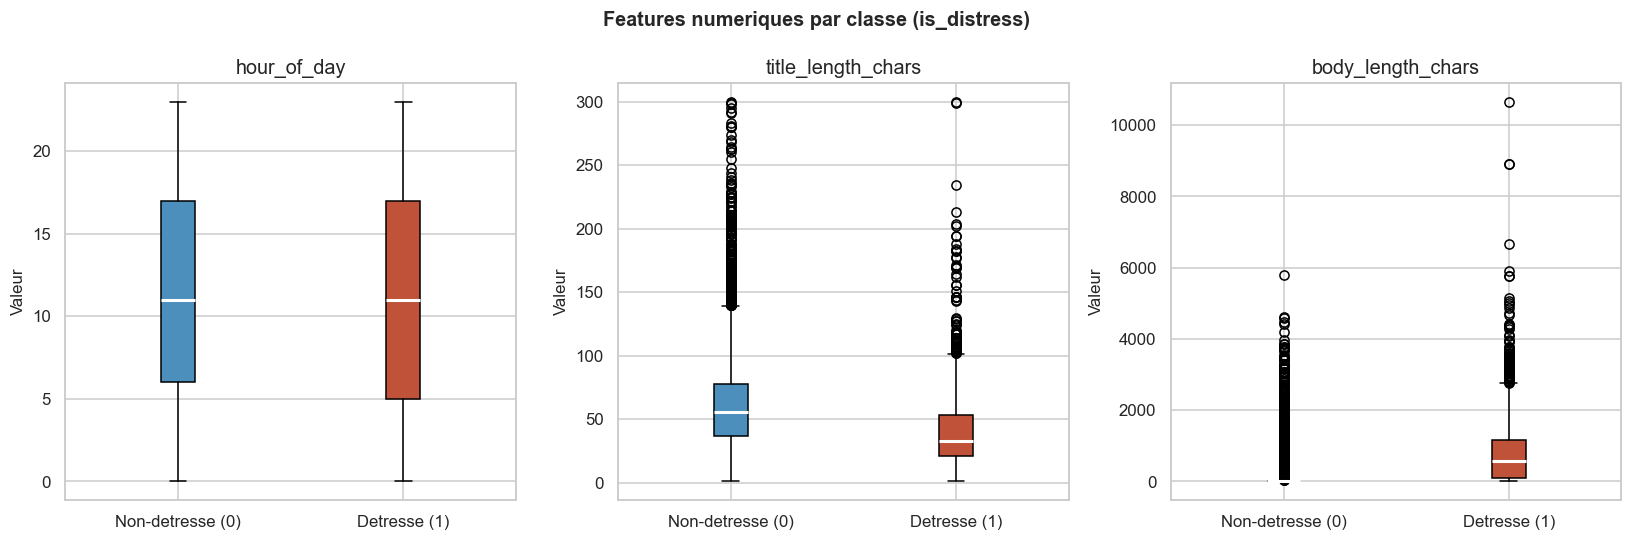

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, num_cols):
    data_0 = df[df['is_distress'] == 0][col]
    data_1 = df[df['is_distress'] == 1][col]
    bp = ax.boxplot(
        [data_0, data_1],
        labels=['Non-detresse (0)', 'Detresse (1)'],
        patch_artist=True,
        medianprops={'color': 'white', 'linewidth': 2}
    )
    bp['boxes'][0].set_facecolor('#4c8fbd')
    bp['boxes'][1].set_facecolor('#c0523a')
    ax.set_title(col)
    ax.set_ylabel('Valeur')

plt.suptitle('Features numeriques par classe (is_distress)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/boxplot_by_class.png', bbox_inches='tight')
plt.show()

In [24]:
means_by_class = df.groupby('is_distress')[num_cols].mean().round(1)
means_by_class.index = ['Non-detresse (0)', 'Detresse (1)']
print(means_by_class.to_string())

                  hour_of_day  title_length_chars  body_length_chars
Non-detresse (0)         11.5                61.2              165.8
Detresse (1)             11.3                41.3              828.2


> **Observations :**
> - `body_length_chars` : les posts de detresse sont **5x plus longs** en moyenne (828 chars vs 166 chars). Signal le plus discriminant parmi les features numeriques.
> - `hour_of_day` : peu de difference entre les deux classes -- faible pouvoir predictif.
> - `title_length_chars` : distributions similaires dans les deux classes.

---
## 8. Analyse des features binaires

In [25]:
binary_cols = ['title_ends_with_question', 'is_nsfw', 'has_url_in_body']

binary_stats = df.groupby('is_distress')[binary_cols].mean().mul(100).round(2)
binary_stats.index = ['Non-detresse (0)', 'Detresse (1)']
binary_stats.columns = ['Titre = question (%)', 'NSFW (%)', 'URL dans le corps (%)']
print(binary_stats.to_string())

                  Titre = question (%)  NSFW (%)  URL dans le corps (%)
Non-detresse (0)                 52.75      1.78                   0.74
Detresse (1)                     18.06      8.89                   0.56


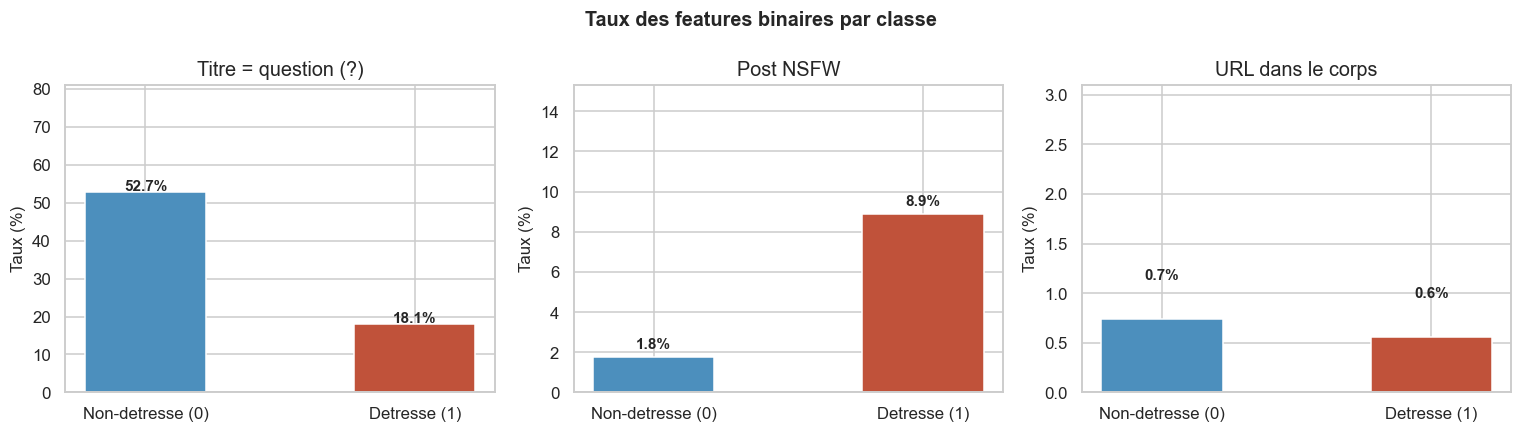

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
class_labels = ['Non-detresse (0)', 'Detresse (1)']
titles_bin   = ['Titre = question (?)', 'Post NSFW', 'URL dans le corps']

for ax, col, title in zip(axes, binary_cols, titles_bin):
    rates = df.groupby('is_distress')[col].mean().mul(100)
    ax.bar(class_labels, rates.values, color=COLORS, edgecolor='white', width=0.45)
    ax.set_title(title)
    ax.set_ylabel('Taux (%)')
    ax.set_ylim(0, max(rates.values) * 1.5 + 2)
    for i, v in enumerate(rates.values):
        ax.text(i, v + 0.4, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Taux des features binaires par classe', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/binary_features_by_class.png', bbox_inches='tight')
plt.show()

> **Observations :**
> - `title_ends_with_question` : les posts non-detresse posent plus souvent des questions (52.8 % vs 18.1 %). Signal negatif pertinent.
> - `is_nsfw` : les posts de detresse sont plus frequemment NSFW (8.9 % vs 1.8 %). Coherent avec des contenus sensibles.
> - `has_url_in_body` : quasi-absent dans les deux classes (< 1 %). Tres faible pouvoir predictif -- candidat a la suppression.

---
## 9. Analyse de `flair_text`

In [27]:
flair_counts = df['flair_text'].value_counts(dropna=True)

print(f'Nombre de valeurs uniques dans flair_text : {df["flair_text"].nunique()}')
print(f'Posts avec flair : {df["flair_text"].notna().sum():,} / {len(df):,} ({df["flair_text"].notna().mean()*100:.1f}%)')
print(f'Posts sans flair : {df["flair_text"].isna().sum():,} ({df["flair_text"].isna().mean()*100:.1f}%)')
print()
print('Top 15 flairs :')
print(flair_counts.head(15).to_string())

Nombre de valeurs uniques dans flair_text : 67
Posts avec flair : 5,116 / 12,000 (42.6%)
Posts sans flair : 6,884 (57.4%)

Top 15 flairs :
flair_text
Question                                          1092
:chat: Just Chatting                               709
Advice Needed                                      550
General Advice                                     396
Software                                           350
Technique                                          300
:question: Questions                               205
:error: Removed                                    194
:story: Life Stories                               131
Venting                                            128
Content Warning: Suicidal Thoughts / Self Harm     120
:thinking: Thoughts & Ideas                        114
Need Support                                        92
Health                                              81
Medication                                          77


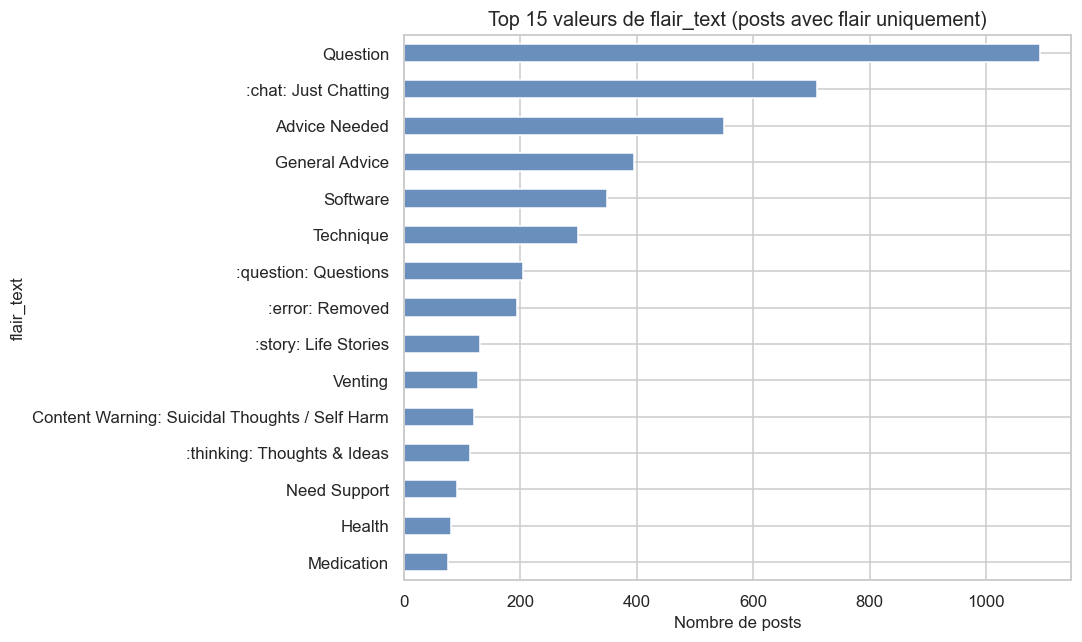

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
flair_counts.head(15).sort_values().plot(
    kind='barh', ax=ax, color='#6a8fbd', edgecolor='white'
)
ax.set_title('Top 15 valeurs de flair_text (posts avec flair uniquement)')
ax.set_xlabel('Nombre de posts')
plt.tight_layout()
plt.savefig('../figures/flair_distribution.png', bbox_inches='tight')
plt.show()

> **Observations :**
> - `flair_text` contient **57.4 % de valeurs manquantes** -- imputation necessaire en Phase 2 (valeur de substitution : `"No Flair"`).
> - Certains flairs sont fortement informatifs : *Content Warning: Suicidal Thoughts*, *Venting*, *Need Support* sont des signaux clairs de detresse.
> - Les flairs rares (< 10 occurrences) seront regroupes en categorie `"Other"` en Phase 2.

---
## 10. Matrice de correlation

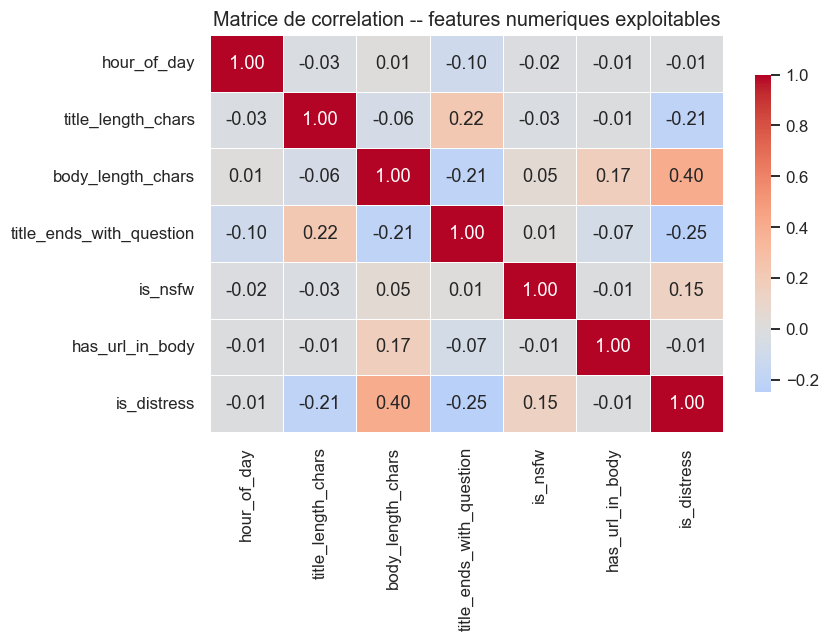

In [29]:
usable_cols = [
    'hour_of_day', 'title_length_chars', 'body_length_chars',
    'title_ends_with_question', 'is_nsfw', 'has_url_in_body', 'is_distress'
]

corr_matrix = df[usable_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Matrice de correlation -- features numeriques exploitables')
plt.tight_layout()
plt.savefig('../figures/correlation_matrix.png', bbox_inches='tight')
plt.show()

In [30]:
target_corr = corr_matrix['is_distress'].drop('is_distress').sort_values(key=abs, ascending=False)
print('Correlation avec is_distress (valeur absolue decroissante) :')
print(target_corr.to_string())

Correlation avec is_distress (valeur absolue decroissante) :
body_length_chars           0.40
title_ends_with_question   -0.25
title_length_chars         -0.21
is_nsfw                     0.15
hour_of_day                -0.01
has_url_in_body            -0.01


> **Observations :**
> - `body_length_chars` presente la correlation la plus elevee avec `is_distress`.
> - `title_ends_with_question` est negativement correlee a `is_distress`.
> - `is_nsfw` presente une correlation positive moderee avec `is_distress`.
> - Peu de multicolinearite entre les features -- propriete favorable pour les modeles lineaires.

---
## 11. Resume des problemes identifies

In [31]:
problems = {
    'Probleme': [
        'Colonnes author_* : 100 % de valeurs a -1',
        'flair_text : 57.4 % de valeurs manquantes',
        'subreddit : correlation parfaite avec is_distress',
        'has_url_in_body : quasi-constante (< 1 %)',
    ],
    'Severite': [
        'Critique',
        'Modere',
        'Critique -- data leakage',
        'Faible',
    ],
    'Action Phase 2': [
        'Supprimer les 3 colonnes',
        'Imputer avec No Flair + regrouper les flairs rares',
        'Supprimer avant entrainement du modele',
        'Supprimer -- variance quasi-nulle',
    ]
}

pd.DataFrame(problems)

,Probleme,Severite,Action Phase 2
0,Colonnes author_* : 100 % de valeurs a -1,Critique,Supprimer les 3 colonnes
1,flair_text : 57.4 % de valeurs manquantes,Modere,Imputer avec No Flair + regrouper les flairs r...
2,subreddit : correlation parfaite avec is_distress,Critique -- data leakage,Supprimer avant entrainement du modele
3,has_url_in_body : quasi-constante (< 1 %),Faible,Supprimer -- variance quasi-nulle


---
## 12. Conclusion

### Conformite aux contraintes du cahier des charges

| Critere | Exigence | Valeur observee | Statut |
|---|---|---|---|
| Taille totale | >= 10 000 lignes | 12 000 lignes | Conforme |
| Classe minoritaire | 5 % -- 25 % | 15 % (1 800 / 12 000) | Conforme |
| Types de variables | Numeriques + categorielles | Oui | Conforme |
| Nombre de features | >= 8 apres feature engineering | 9 avant nettoyage | Conforme |

### Points d'attention pour la Phase 2

| Probleme | Action |
|---|---|
| Colonnes `author_*` inutilisables (100 % de -1) | Supprimer |
| `subreddit` : data leakage direct vers la cible | Supprimer avant entrainement |
| `flair_text` : 57.4 % de valeurs manquantes | Imputation + regroupement des flairs rares |
| `has_url_in_body` : quasi-constante | Candidat a la suppression |

### Features les plus prometteuses

| Feature | Signal |
|---|---|
| `body_length_chars` | Posts de detresse 5x plus longs -- signal le plus fort |
| `flair_text` | Tres informatif quand disponible (Venting, Need Support...) |
| `is_nsfw` | Positivement correle a la detresse (8.9 % vs 1.8 %) |
| `title_ends_with_question` | Signal negatif : la detresse pose moins de questions |

---

